# Ставка ЦБ, курс рубля и его волатильность

**Авторы:** Анастасия Казакова, Степан Селезнев, Светлана Калошкина.

Финальный проект по предмету «Анализ экономических данных», 2026 год.

**Исследовательский вопрос:** помогают ли прошлые изменения ключевой ставки прогнозировать изменения курса рубля?

**Дополнительный вопрос:** как различается волатильность курса в окнах вокруг вступления изменений ставки в силу и в сопоставимых временных окнах?

Курс влияет на рублёвую стоимость импорта, валютных обязательств и сбережений. Исследование оценивает временную связь и дополнительную предсказуемость. Причинное влияние денежной политики требует отдельного дизайна с идентифицированным шоком.

Порядок запуска: установите библиотеки из `requirements.txt`, откройте ноутбук из папки проекта и выполните все ячейки. Исходные данные приложены. Команда `python analysis.py` воспроизводит те же таблицы и графики.


In [1]:
import json
import subprocess
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "analysis.py").is_file():
    raise RuntimeError("Откройте ноутбук из корневой папки проекта, рядом с analysis.py.")
completed = subprocess.run([sys.executable, str(ROOT / "analysis.py")], cwd=ROOT, text=True, encoding="utf-8", capture_output=True)
if completed.returncode:
    print(completed.stdout)
    print(completed.stderr)
    raise RuntimeError("Расчёт остановлен. Подробности в output/run.log.")
manifest = json.loads((ROOT / "output" / "run_manifest.json").read_text(encoding="utf-8"))
print(f"Все семь этапов выполнены. Время: {manifest['elapsed_seconds']:.2f} с.")
print("Полный журнал: output/run.log")
print("Авторы: " + ", ".join(manifest["authors"]))


Все семь этапов выполнены. Время: 10.12 с.
Полный журнал: output/run.log
Авторы: Анастасия Казакова, Степан Селезнев, Светлана Калошкина


In [2]:
import pandas as pd
from IPython.display import Image

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)


## Данные и аналитическая выборка

Источники: [ключевая ставка Банка России](https://www.cbr.ru/hd_base/KeyRate/), [официальный курс USD/RUB](https://www.cbr.ru/currency_base/dynamics/), [Brent, FRED DCOILBRENTEU](https://fred.stlouisfed.org/series/DCOILBRENTEU).

Ставка измеряется в процентах годовых, курс в рублях за доллар, Brent в долларах за баррель. На дневной частоте одна строка соответствует опубликованному наблюдению официального курса. Месячная панель объединяет ставку на конец месяца и средние значения курса и нефти. Основная модель использует полные месяцы общего периода источников.

Даты приведены к единому формату, курс пересчитан на один доллар с учётом nominal. Повторяющиеся и конфликтующие даты в снимке отсутствуют. Строки Brent без числовой цены исключаются до агрегирования; средние рассчитываются по доступным наблюдениям. В исходной полной истории Brent 1173 таких строки из 10265. Заполнение цен и винзоризация не применяются. Кризисные значения сохранены; их роль проверяется альтернативными спецификациями. Основная месячная панель после объединения содержит 155 последовательных месяцев без пропусков. Аудит исходных строк и границ сохранён в `output/tables/T0_data_audit.json`.

Исходные файлы сохранены отдельно от преобразованных. Их SHA-256 проверяется перед расчётом. Данные о курсе после 13 июня 2024 года основаны на изменённой методике Банка России, использующей внебиржевые операции. Это ограничение сопоставимости волатильности отражено в интерпретации.


In [3]:
pd.read_csv(ROOT / "output" / "tables" / "T1_sample.csv")


,series,n_obs,date_min,date_max,value_min,value_max,value_mean
0,key_rate,3264,2013-09-17,2026-09-23,4.2500,21.0000,10.409620
1,usdrub,3385,2013-01-10,2026-09-23,29.9251,120.3785,66.834540
2,brent,3481,2013-01-02,2026-09-22,9.1200,138.2100,73.210684


In [4]:
monthly = pd.read_parquet(ROOT / "data" / "processed" / "monthly_panel.parquet")
daily = pd.read_parquet(ROOT / "data" / "processed" / "daily_returns.parquet")
pd.DataFrame([
    {"выборка": "месячная панель", "строк": len(monthly), "начало": monthly["date"].min(), "конец": monthly["date"].max()},
    {"выборка": "дневные доходности", "строк": len(daily), "начало": daily["date"].min(), "конец": daily["date"].max()},
])


,выборка,строк,начало,конец
0,месячная панель,155,2013-10-31,2026-08-31
1,дневные доходности,3214,2013-09-17,2026-09-23


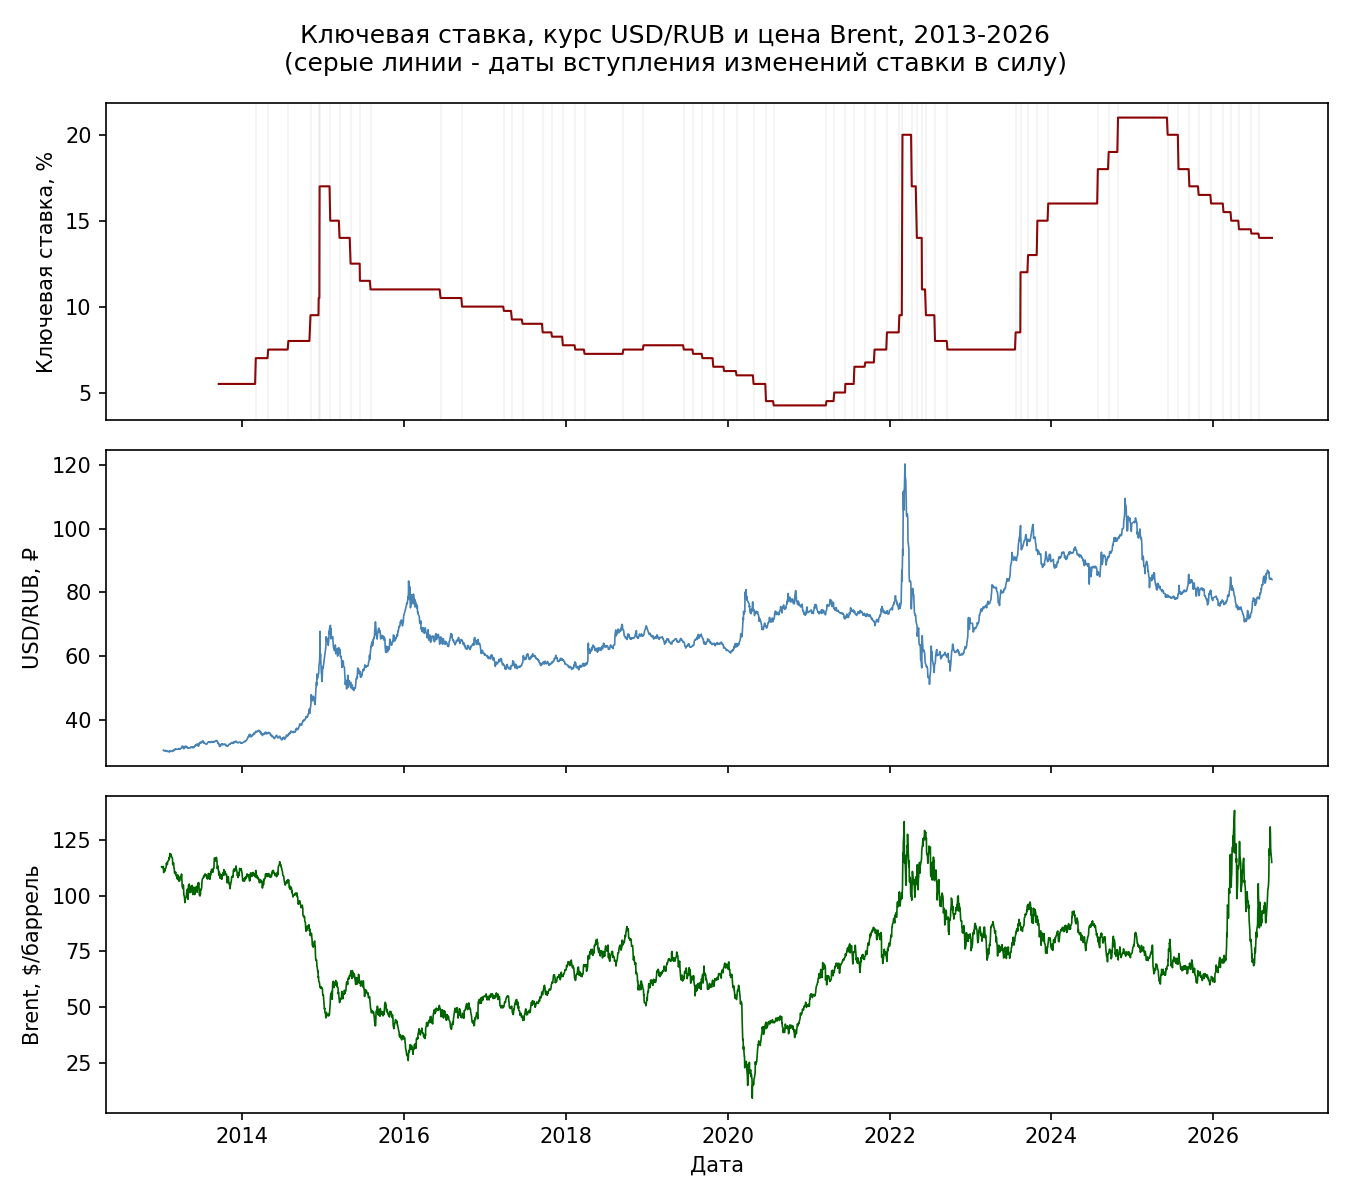

In [5]:
Image(filename=str(ROOT / "output" / "figures" / "R1_three_series.png"))


## Стационарность и выбор спецификации

ADF и KPSS проверяют свойства рядов при разных детерминированных компонентах. В модели используются изменения ставки и логарифмические изменения курса и Brent. Таблица позволяет сопоставить тесты фактически моделируемых преобразований. Окончательное решение учитывает результаты тестов, экономический смысл и диагностику модели.

Порядок лагов и чувствительность ранга коинтеграции сохраняются в отдельном протоколе. Альтернативная спецификация помогает оценить зависимость результата от предположений.


In [6]:
pd.read_csv(ROOT / "output" / "tables" / "T2_stationarity.csv")


,variable,scale,transform,regression,n_obs,adf_stat,adf_p,kpss_stat,kpss_p,kpss_p_is_table_bound
0,key_rate,percentage_points,model_level,c,155,-1.906771,3.288828e-01,0.660651,0.017123,False
1,key_rate,percentage_points,model_level,ct,155,-2.091472,5.508686e-01,0.287119,0.010000,True
2,key_rate,percentage_points,model_diff,c,154,-8.146293,9.968266e-13,0.054473,0.100000,True
3,key_rate,percentage_points,model_diff,ct,154,-8.120651,3.759316e-11,0.058032,0.100000,True
4,usdrub,log,model_level,c,155,-2.946984,4.015085e-02,1.255261,0.010000,True
5,usdrub,log,model_level,ct,155,-3.767842,1.826075e-02,0.114836,0.100000,True
6,usdrub,log,model_diff,c,154,-8.116686,1.185784e-12,0.154278,0.100000,True
7,usdrub,log,model_diff,ct,154,-8.220251,2.213241e-11,0.052769,0.100000,True
8,brent,log,model_level,c,155,-2.612089,9.052445e-02,0.340962,0.100000,True
9,brent,log,model_level,ct,155,-3.043054,1.204389e-01,0.140836,0.059562,False


In [7]:
print((ROOT / "data" / "processed" / "var_spec_decision.txt").read_text(encoding="utf-8"))


BIC для VAR в уровнях: p=3; k_ar_diff=2.
BIC для VAR в разностях: p=2.
Основная модель: VAR(2) изменений ставки и логарифмов курса/Brent.
Лаг 2 фиксирован для базовой модели и прогноза; лаги 1 и 3 проверяются отдельно.
Тест Йохансена служит диагностикой чувствительности долгосрочной спецификации.
Его интерпретация предполагает интеграцию рядов первого порядка; ADF/KPSS дают ограничения.
k_ar_diff=0: rank=0
r<=0: trace=14.9170, critical_95=29.7961, reject=False
r<=1: trace=5.6176, critical_95=15.4943, reject=False
r<=2: trace=0.1489, critical_95=3.8415, reject=False
k_ar_diff=1: rank=3
r<=0: trace=34.3251, critical_95=29.7961, reject=True
r<=1: trace=16.7027, critical_95=15.4943, reject=True
r<=2: trace=5.5598, critical_95=3.8415, reject=True
k_ar_diff=2: rank=0
r<=0: trace=24.8930, critical_95=29.7961, reject=False
r<=1: trace=12.8221, critical_95=15.4943, reject=False
r<=2: trace=5.5950, critical_95=3.8415, reject=True
k_ar_diff=3: rank=0
r<=0: trace=23.4385, critical_95=29.7961, reje

In [8]:
pd.read_csv(ROOT / "output" / "tables" / "T3_lag_selection.csv")


,scale,criterion,selected_lag,baseline_fixed_lag
0,levels,aic,3,2
1,levels,bic,3,2
2,levels,hqic,3,2
3,levels,fpe,3,2
4,differences,aic,2,2
5,differences,bic,2,2
6,differences,hqic,2,2
7,differences,fpe,2,2


## Предсказуемость внутри выборки

Тест Грейнджера проверяет, добавляют ли лаги одного ряда информацию в уравнение другого при заданной модели. Его p-значение относится к совместной гипотезе о коэффициентах. Экономическую величину связи следует оценивать отдельно. Отсутствие статистической значимости оставляет неопределённость относительно размера связи.


In [9]:
pd.read_csv(ROOT / "output" / "tables" / "T4_granger.csv")


,spec,spec_note,control,causing,caused,f_stat,p_value,conclusion
0,VAR-в-разностях (осн.),основная спецификация,с нефтью в системе,key_rate,usdrub,49.504478,4.261925e-20,отвергаем H0 (есть предсказуемость)
1,VAR-в-разностях (осн.),основная спецификация,с нефтью в системе,usdrub,key_rate,5.419257,4.734662e-03,отвергаем H0 (есть предсказуемость)
2,VAR-в-разностях (осн.),основная спецификация,без нефти,key_rate,usdrub,49.987226,2.057087e-19,отвергаем H0 (есть предсказуемость)
3,VAR-в-разностях (осн.),основная спецификация,без нефти,usdrub,key_rate,5.237179,5.822390e-03,отвергаем H0 (есть предсказуемость)
4,VECM (kd=1),условная чувствительность при rank=1 и k_ar_di...,с нефтью (в системе),key_rate,usdrub,51.590666,8.639386e-21,отвергаем H0 (есть предсказуемость)
5,VECM (kd=1),условная чувствительность при rank=1 и k_ar_di...,с нефтью (в системе),usdrub,key_rate,4.964009,7.394276e-03,отвергаем H0 (есть предсказуемость)


## Чувствительность к кризисным эпизодам

Проверки меняют лаг, состав периода и способ месячного агрегирования. Отдельные индикаторы выделяют выбранные кризисные наблюдения и затрагиваемые ими лаги. Это диагностическое сравнение спецификаций. Оно показывает чувствительность оценки к кризисной динамике.

Скользящие окна перекрываются и используют одни и те же наблюдения многократно. Долю значимых окон следует читать как описательную характеристику этой процедуры. Формальные тесты отдельных окон требуют осторожности из-за множественных сравнений.


In [10]:
pd.read_csv(ROOT / "output" / "tables" / "T7_robustness.csv")


,check,variant,n_obs,rate_to_fx_p,fx_to_rate_p,conclusion
0,альтернативный лаг,VAR(1),153,1.733642e-09,9.818264e-03,"p<0.05: ставка→курс, курс→ставка"
1,альтернативный лаг,VAR(2) (основной),152,4.261925e-20,4.734662e-03,"p<0.05: ставка→курс, курс→ставка"
2,альтернативный лаг,VAR(3),151,2.793638e-17,4.294179e-02,"p<0.05: ставка→курс, курс→ставка"
3,подпериод,до 28.02.2022 (вкл. кризис 2014-15),97,6.481523e-02,4.164160e-02,p<0.05: курс→ставка
4,подпериод,после 28.02.2022 (вкл. острую фазу 2022),52,7.844852e-01,1.048635e-05,p<0.05: курс→ставка
5,подпериод,спокойный период 2015-06..2021-12 (основной),76,5.437274e-01,3.692403e-01,оба p>=0.05; отсутствие связи не установлено
6,подпериод,"спокойный период, начало сдвинуто на 7 мес.: 2...",69,3.155969e-01,5.444677e-01,оба p>=0.05; отсутствие связи не установлено
7,подпериод,"спокойный период, конец сдвинут на 6 мес.: 201...",70,4.475426e-01,4.839386e-02,p<0.05: курс→ставка
8,подпериод,после острой фазы 2022-09..,45,7.423434e-01,3.633128e-01,оба p>=0.05; отсутствие связи не установлено
9,подпериод,"до смены измерения курса, полные месяцы по 202...",125,1.498016e-18,2.261722e-03,"p<0.05: ставка→курс, курс→ставка"


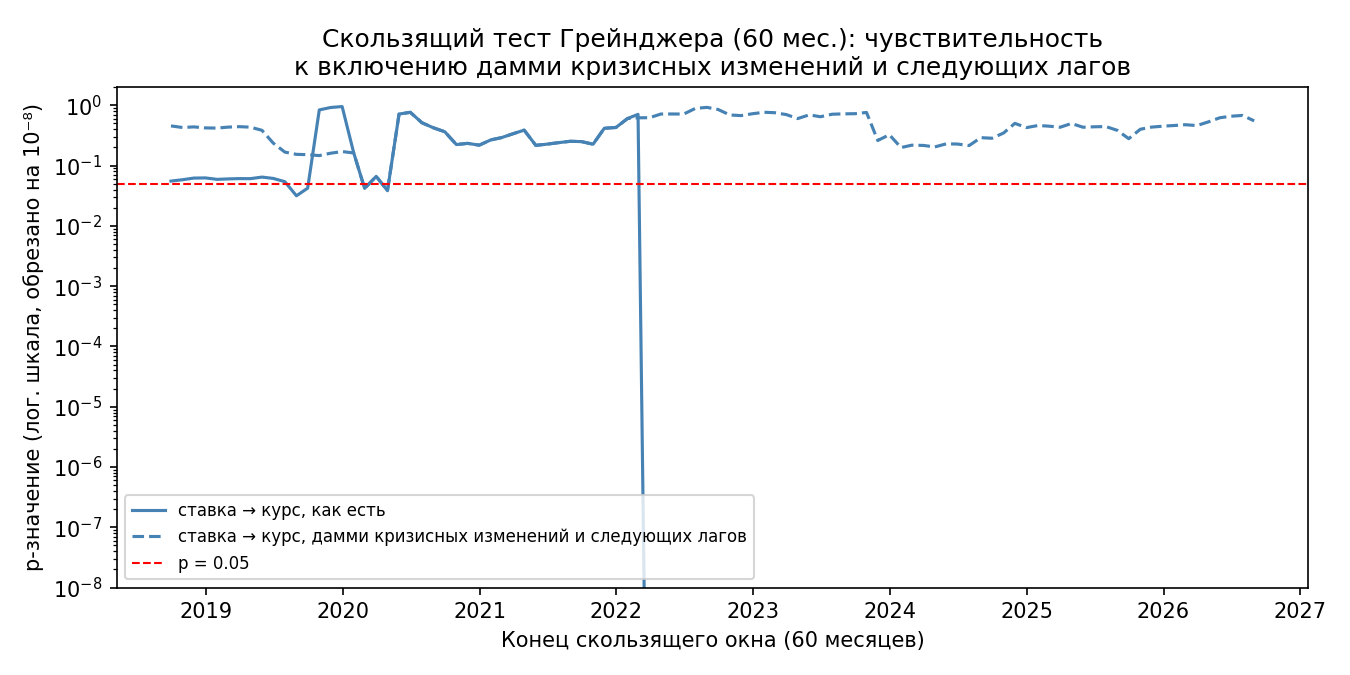

In [11]:
Image(filename=str(ROOT / "output" / "figures" / "R4_rolling_granger.png"))


In [12]:
pd.read_csv(ROOT / "output" / "tables" / "T7d_effect_size.csv")


,lag_order,sum_rate_lag_coefficients,ci_lo,ci_hi,interpretation
0,2,0.000514,-0.007799,0.008826,сумма условных коэффициентов уравнения Δlog ку...


## Импульсные отклики

Размер импульса нормирован на 1 процентный пункт ключевой ставки. Порядок переменных задаёт допущения при разложении ковариации ошибок. Отклик изменения логарифма курса и накопленная траектория показаны отдельно.

Интервалы получены остаточным бутстрапом. Для накопленного отклика сначала суммируется каждая отдельная бутстрап-траектория, затем рассчитываются её квантили. Интервалы отражают неопределённость в рамках выбранной модели и допущений о шоках. Интервалы точечные для каждого горизонта. Остаточный iid-бутстрап предполагает одинаковое распределение инноваций во времени. Кризисная неоднородность волатильности ограничивает применимость этого приближения.


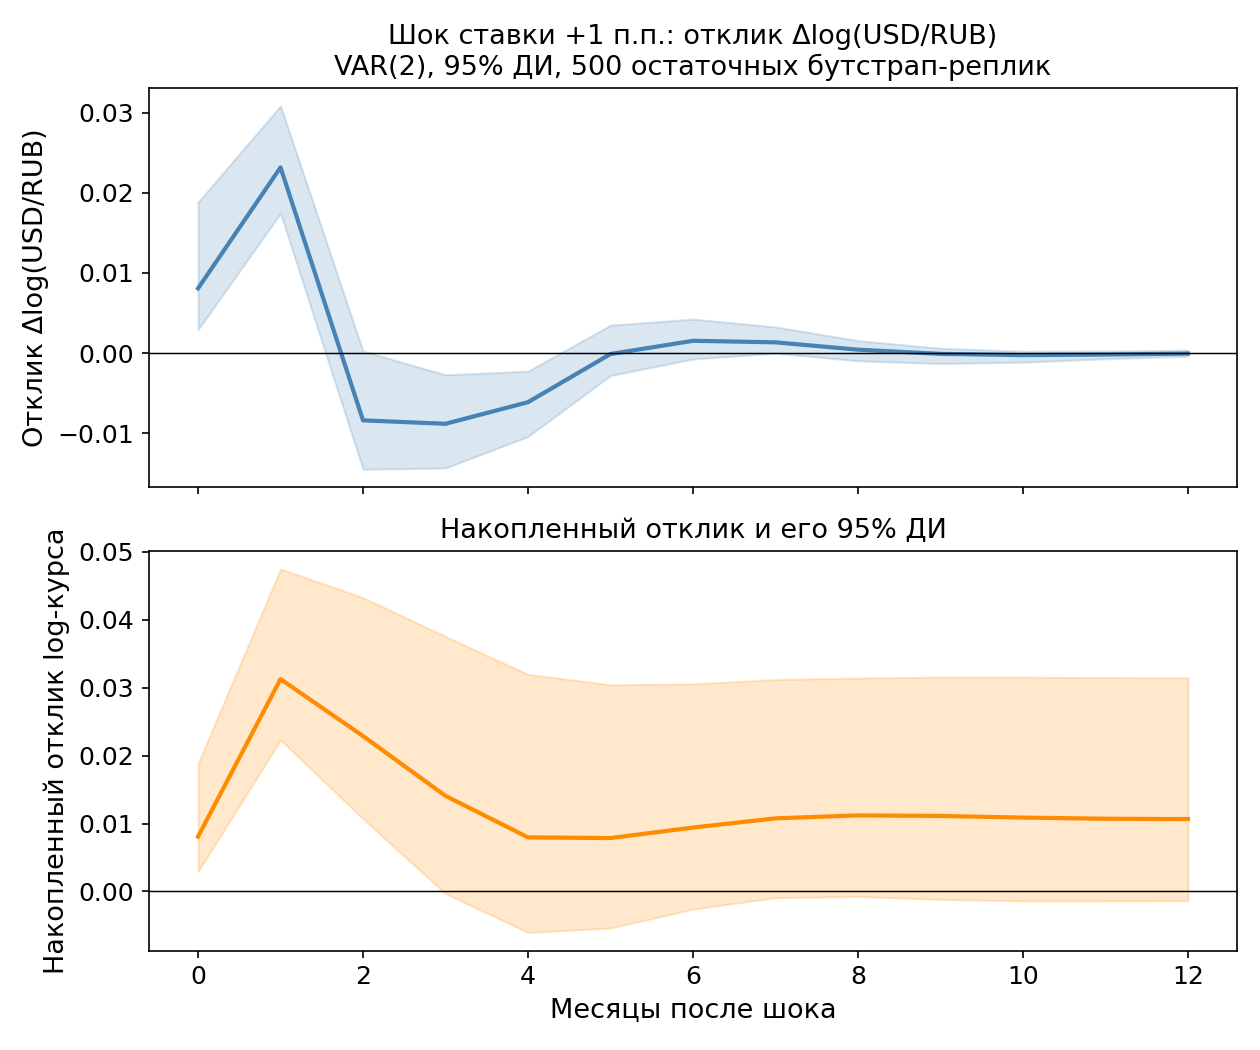

In [13]:
Image(filename=str(ROOT / "output" / "figures" / "R2_irf_rate_to_fx.png"))


In [14]:
pd.read_csv(ROOT / "output" / "tables" / "T3c_irf_bootstrap.csv")


,horizon,response_per_pp,ci_lo,ci_hi,cum_response_per_pp,cum_ci_lo,cum_ci_hi
0,0,0.008082,0.002939,0.018824,0.008082,0.002939,0.018824
1,1,0.023168,0.017444,0.030846,0.031250,0.022294,0.047465
2,2,-0.008376,-0.014478,0.000260,0.022873,0.010698,0.043257
3,3,-0.008803,-0.014316,-0.002690,0.014070,-0.000316,0.037538
4,4,-0.006108,-0.010390,-0.002240,0.007963,-0.006020,0.031952
5,5,-0.000100,-0.002774,0.003499,0.007863,-0.005378,0.030424
6,6,0.001546,-0.000727,0.004254,0.009409,-0.002596,0.030544
7,7,0.001353,-0.000005,0.003277,0.010762,-0.000917,0.031199
8,8,0.000438,-0.000946,0.001572,0.011200,-0.000734,0.031409
9,9,-0.000083,-0.001292,0.000618,0.011117,-0.001168,0.031555


In [15]:
pd.read_csv(ROOT / "output" / "tables" / "T7b_irf_ordering.csv")


,ordering,peak_horizon,peak_value_per_pp,sign,cum_effect_h3_per_pp,own_shock_per_pp,note
0,"key_rate, usdrub, brent (основной)",1,0.023168,+,0.014070,1.0,нормировка на собственный одновременный импуль...
1,"usdrub, key_rate, brent",1,0.020147,+,0.001715,1.0,нормировка на собственный одновременный импуль...
2,"brent, key_rate, usdrub",1,0.023140,+,0.014011,1.0,нормировка на собственный одновременный импуль...


## Условная волатильность

Кандидаты GARCH различаются распределением ошибок, моделью среднего и асимметрией волатильности. Информационные критерии сравниваются на согласованной выборке. После выбора проверяются стандартизированные остатки и их квадраты.

Диагностика ограничивает доверие к отдельным подвыборкам. При граничной персистентности интерпретация безусловной дисперсии требует особой осторожности.


In [16]:
pd.read_csv(ROOT / "output" / "tables" / "T5b_garch_spec_selection.csv")


,spec,aic,bic,loglik,n_obs,convergence_flag
0,"t, AR(1)-mean, GJR",7973.127041,8015.651764,-3979.563521,3213,0
1,"t, AR(1)-mean",7997.853367,8034.303129,-3992.926683,3213,0
2,"t, const-mean",8030.935428,8061.310229,-4010.467714,3213,0
3,"Normal, const-mean",8306.740762,8331.040604,-4149.370381,3213,0


In [17]:
pd.read_csv(ROOT / "output" / "tables" / "T5_garch.csv")


,period,n_obs,convergence_flag,omega,alpha,gamma_asym,beta,persistence,unconditional_var_pct2,ljung_box_resid_p,ljung_box_resid_sq_p
0,весь период,3213,0,0.037628,0.287949,-0.159207,0.776666,0.985011,2.510390,0.208916,4.947373e-01
1,до 28.02.2022,2081,0,0.014545,0.165541,-0.129345,0.885829,0.986697,1.093423,0.547353,6.658335e-01
2,после 28.02.2022,1131,0,0.122708,0.476971,-0.094979,0.570518,1.000000,NaN,0.600657,6.083087e-08
3,до смены измерения 13.06.2024,2646,0,0.029544,0.258507,-0.160756,0.807141,0.985271,2.005771,0.424591,6.714305e-01
4,после смены измерения 13.06.2024,566,0,0.105724,0.305143,-0.031451,0.630576,0.919993,1.321429,0.840952,6.588980e-01


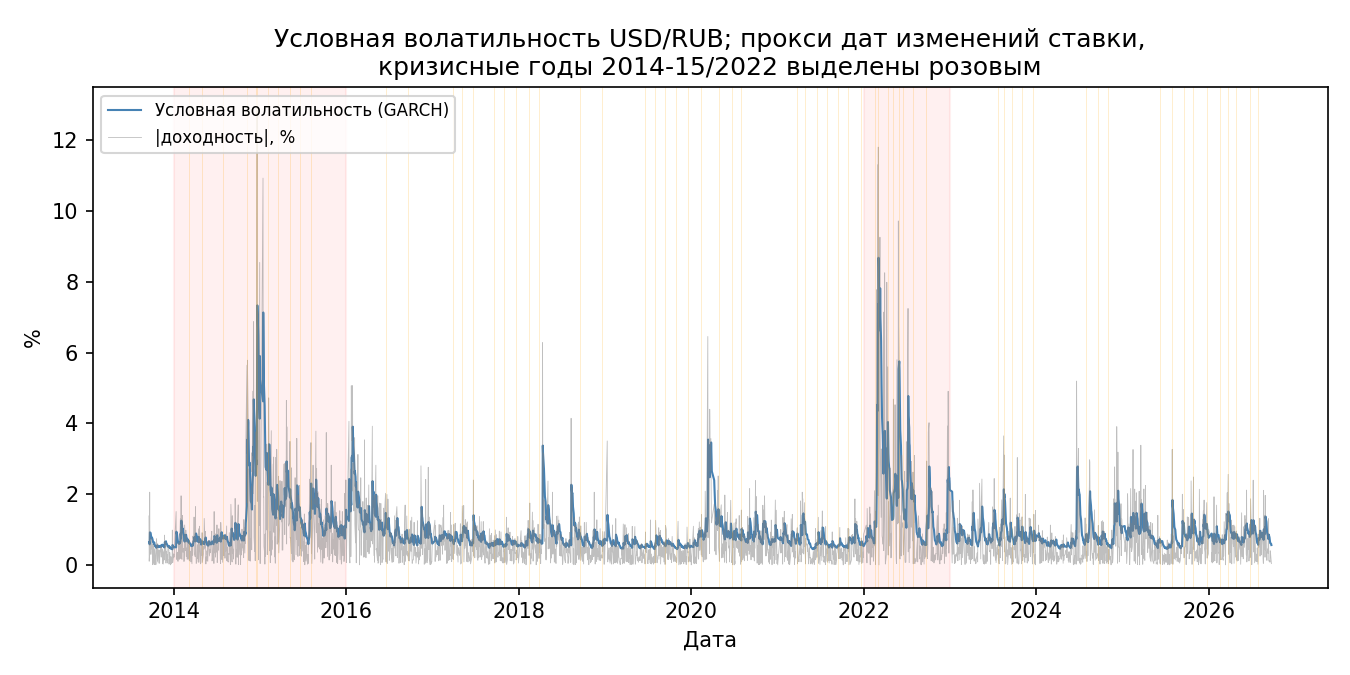

In [18]:
Image(filename=str(ROOT / "output" / "figures" / "R3_conditional_volatility.png"))


## Окна вокруг вступления изменений ставки в силу

События выделены из изменений опубликованного ряда ставки. Центр привязан к первому наблюдению фиксинга после даты вступления изменения в силу. Это операционное определение отличается от календаря публикации объявлений. Заседания с сохранением ставки требуют отдельного календаря для построения контрольной группы.

Для каждого окна оценивается абсолютная доходность и её отличие от предшествующего базового периода. При исключении отдельных лет сохраняется исходная последовательность дат. Плацебо учитывает год события. Сопоставление остаётся описательным: плановость решения, ожидания и кризисные новости могут объяснять часть различий.


In [19]:
pd.read_csv(ROOT / "output" / "tables" / "T6_event_study.csv")


,test,n_events,observed_abs_return_pct,placebo_abs_return_mean,p_value_abs_return,n_exceed_abs_return,observed_cond_vol,placebo_cond_vol_mean,p_value_cond_vol,n_exceed_cond_vol,n_permutations,seed
0,"описательное сравнение с глобальным плацебо, р...",65,0.962362,0.686768,0.000999,0,1.195346,0.958289,0.002997,2,1000,20260101


In [20]:
pd.read_csv(ROOT / "output" / "tables" / "T6b_event_study_stratified.csv")


,n_events,n_years,observed_abnormal_abs_return_pct,placebo_abnormal_mean,placebo_abnormal_p95,p_value,n_exceed,n_permutations,seed,event_window_obs,baseline_obs,inference,subset
0,65,13,0.125223,-0.017032,0.070198,0.003996,3,1000,20260101,11,30,описательное Monte Carlo сравнение; сопоставим...,"все события (плацебо по годам, аномальная |r|)"
1,46,10,0.000090,-0.008127,0.069028,0.415584,415,1000,20260101,11,30,описательное Monte Carlo сравнение; сопоставим...,без 2014/2015/2022 (кризисные годы)


In [21]:
pd.read_csv(ROOT / "output" / "tables" / "T6c_before_after.csv")


,n_events,pre_proxy_abs_return_pct,post_proxy_abs_return_pct,baseline_30obs_before_window_pct,pre_window_obs,post_window_obs,subset
0,65,0.838219,1.065814,0.837139,5,6,все события
1,46,0.568322,0.569509,0.568879,5,6,без 2014/2015/2022 (кризисные годы)


## Проверка прогноза на последующих наблюдениях

Обучающее окно последовательно расширяется. Каждый прогноз использует наблюдения до соответствующей временной границы. Проверка псевдовневыборочная: исторические версии данных и точные моменты публикации показателей не восстановлены. Сравниваются прогноз нулевого изменения, модель курса с нефтью и модель с добавленной ставкой.

Целевая величина: месячное логарифмическое изменение курса на заданном горизонте. Для более длинного горизонта это изменение в целевом месяце. RMSE и MAE сравниваются на общих конечных наблюдениях. В кризисной части прогнозной выборки число наблюдений невелико; точность оценки различий ограничена. Для вложенных одношаговых прогнозов используется приближённый тест Кларка-Уэста с HAC на всей непрерывной прогнозной выборке. Разбиение по режимам служит описательным сравнением.


In [22]:
pd.read_csv(ROOT / "output" / "tables" / "T8_outofsample_summary.csv")


,regime,h,n,target_min,target_max,rmse_naive,mae_naive,rmse_var2_no_rate,mae_var2_no_rate,rmse_var3_with_rate,mae_var3_with_rate
0,вся OOS-выборка,1,118,2016-11-30,2026-08-31,0.054766,0.032708,0.069435,0.036517,0.054131,0.034410
1,вся OOS-выборка,2,117,2016-12-31,2026-08-31,0.054944,0.032759,0.060132,0.036118,0.061066,0.038174
2,вся OOS-выборка,3,116,2017-01-31,2026-08-31,0.055084,0.032738,0.057017,0.035645,0.056860,0.036362
3,"кризисные цели, доступный год: 2022",1,12,2022-01-31,2022-12-31,0.138386,0.091643,0.191626,0.116199,0.127414,0.075699
4,"кризисные цели, доступный год: 2022",2,12,2022-01-31,2022-12-31,0.138386,0.091643,0.151638,0.095340,0.152779,0.109067
5,"кризисные цели, доступный год: 2022",3,12,2022-01-31,2022-12-31,0.138386,0.091643,0.140785,0.092629,0.139693,0.098812
6,остальные годы OOS-выборки,1,106,2016-11-30,2026-08-31,0.034217,0.026036,0.034784,0.027496,0.037737,0.029736
7,остальные годы OOS-выборки,2,105,2016-12-31,2026-08-31,0.034281,0.026029,0.037432,0.029350,0.038570,0.030072
8,остальные годы OOS-выборки,3,104,2017-01-31,2026-08-31,0.034272,0.025942,0.036594,0.029070,0.036803,0.029156


In [23]:
pd.read_csv(ROOT / "output" / "tables" / "T8b_clark_west.csv")


,restricted_model,unrestricted_model,h,n,hac_lags,mean_raw_loss_difference,mean_adjusted_loss_difference,hac_standard_error,z_stat,p_one_sided,conclusion,method
0,naive,var3_with_rate,1,118,4,0.000069,0.001425,0.000830,1.716198,0.043063,приближённый тест поддерживает добавочную прог...,"Clark-West для вложенных моделей, HAC Bartlett..."
1,var2_no_rate,var3_with_rate,1,118,4,0.001891,0.003073,0.002682,1.145540,0.125993,добавочная прогнозная информация не подтвержде...,"Clark-West для вложенных моделей, HAC Bartlett..."


Метод сравнения вложенных моделей: [Clark и West, RWP 05-05](https://www.kansascityfed.org/documents/5368/pdf-RWP05-05.pdf). Поправка учитывает шум оценки дополнительных параметров. Применяется односторонняя нормальная аппроксимация и HAC Bartlett с четырьмя лагами. При гетероскедастичности, нескольких добавочных параметрах и расширяющемся окне такая аппроксимация имеет исследовательский характер. Для более сильного вывода необходима специальная калибровка теста.


## Независимая проверка результатов

Скрипт `verify_results.py` отдельно проверяет исходные хеши, подготовку данных и ключевые численные результаты. Манифест связывает проверку с конкретными версиями кода и таблиц.


In [24]:
checked = subprocess.run([sys.executable, str(ROOT / "verify_results.py")], cwd=ROOT, text=True, encoding="utf-8", capture_output=True)
print(checked.stdout)
if checked.returncode:
    print(checked.stderr)
    raise RuntimeError("Независимая проверка завершилась ошибкой.")


{"status": "PASS", "checks": 8, "elapsed_seconds": 0.3944147080183029, "error": null}



## Интерпретация и подготовка к защите

**Ответ:** прогнозная связь присутствует в отдельных спецификациях, а её устойчивость и дополнительная практическая полезность ограничены. Результат зависит от эталонного прогноза, метрики и периода.

В полной выборке p Грейнджера для направления ставка → курс составляет 4,26 × 10⁻²⁰. При индикаторах обоих кризисов и затрагиваемых ими лагов p = 0,778. Это диагностическая чувствительность оценки. Сравнение значимости само по себе не является тестом различия коэффициентов.

На 118 одношаговых прогнозах RMSE полной VAR равна 0,05413, нулевого прогноза 0,05477, VAR курса и нефти 0,06943. По MAE нулевой прогноз точнее полной VAR: 0,03271 против 0,03441. Clark-West даёт p = 0,043 относительно нулевого прогноза и p = 0,126 для добавления ставки к VAR курса и нефти. Первый результат относится ко всей расширенной модели; непосредственно добавочную информацию ставки проверяет второе сравнение. p = 0,043 находится близко к условной границе 5% и зависит от применимости аппроксимации.

В 65 событийных окнах аномальная абсолютная доходность составляет 0,1252 процентного пункта, p плацебо = 0,0040. После исключения 2014, 2015 и 2022 годов остаётся 46 событий: оценка близка к нулю, p = 0,416. Трактовка относится к окнам вокруг вступления изменений ставки в силу.

Ключевые ограничения: агрегированные месячные данные, официальная методика курса, короткие кризисные подвыборки, выбранные окна и лаги, ожидания и макроэкономические факторы за пределами модели. Для оценки причинного эффекта потребуются дополнительные данные и отдельная стратегия идентификации.

Перед выступлением объясните своими словами: почему используются изменения логарифмов, что проверяет Грейнджер, как определяется событие, откуда берётся размер шока и какие данные доступны каждой прогнозной модели. Материалы для репетиции находятся в `defense/`.
